# Identifying Emerging Research Topics
Julien Garcia, 2017699

## About
This section identifies emerging research topics in the DBLP dataset by analyzing paper titles, abstracts, years, and venues. The goal is to discover major research themes, track how they change over time, and compare how quickly different venues adopt those topics.

## Tasks
- use TF-IDF features from paper titles and abstracts
- apply topic modeling to discover latent research themes
- track topic prevalence from 2000 to 2017
- identify topics that grew the most over time
- compare topic adoption across major venues
- use representative papers as case studies

## Motivations
- ...

## Challenges
- ...

In [30]:
"""Import dependencies"""
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF


In [2]:
"""globals constants"""
START_YEAR = 2000
END_YEAR = 2017

MAX_FEATURES = 5000
NUM_TOPICS = 10
TOP_WORDS_PER_TOPIC = 12

SAMPLE_SIZE = 100000
RANDOM_STATE = 42

EARLY_START = 2000
EARLY_END = 2005
LATE_START = 2012
LATE_END = 2017

TOP_VENUES = 10
TOP_CASES = 3

In [3]:
"""helper functions"""
def get_top_words(model, feature_names, n_words=10):
    # get the main words for each topic
    rows = []
    for topic_index, topic_weights in enumerate(model.components_):
        top_indices = topic_weights.argsort()[::-1][:n_words]
        top_words = [feature_names[i] for i in top_indices]

        rows.append({
            "topic_id": topic_index,
            "top_words": ", ".join(top_words)
        })
    return pd.DataFrame(rows)

def label_topic(top_words):
    words = top_words.lower()
    if any(term in words for term in ["neural", "deep", "learning", "classification", "prediction"]):
        return "machine learning"
    elif any(term in words for term in ["image", "vision", "recognition", "object", "feature"]):
        return "computer vision"
    elif any(term in words for term in ["data", "mining", "query", "database", "web"]):
        return "data mining databases"
    elif any(term in words for term in ["wireless", "sensor", "routing", "mobile", "network"]):
        return "networks wireless systems"
    elif any(term in words for term in ["software", "program", "code", "testing"]):
        return "software engineering"
    elif any(term in words for term in ["security", "privacy", "attack", "encryption"]):
        return "security privacy"
    elif any(term in words for term in ["cloud", "distributed", "parallel", "computing"]):
        return "distributed cloud computing"
    elif any(term in words for term in ["social", "user", "recommendation", "online"]):
        return "social recommender systems"
    else:
        return "mixed topic"

In [4]:
"""load shared preprocessed data"""
papers = pd.read_pickle("cleaned_dataset.pkl")
papers.head()

,abstract,authors,n_citation,references,title,venue,year,id
0,The purpose of this study is to develop a lear...,"[makoto satoh, ryo muramatsu, mizue kayama, ka...",0,"[51c7e02e-f5ed-431a-8cf5-f761f266d4be, 69b625b...",Preliminary Design of a Network Protocol Learn...,international conference on human-computer int...,2013,00127ee2-cb05-48ce-bc49-9de556b93346
1,This paper describes the design and implementa...,"[gareth beale, graeme earl]",50,"[10482dd3-4642-4193-842f-85f3b70fcf65, 3133714...",A methodology for the physically accurate visu...,visual analytics science and technology,2011,001c58d3-26ad-46b3-ab3a-c1e557d16821
2,This article applied GARCH model instead AR or...,"[altaf hossain, faisal zaman, mohammed nasser,...",50,"[2d84c0f2-e656-4ce7-b018-90eda1c132fe, a083a1b...","Comparison of GARCH, Neural Network and Suppor...",pattern recognition and machine intelligence,2009,001c8744-73c4-4b04-9364-22d31a10dbf1
3,NaN,"[jea-bum park, byungmok kim, jian shen, sun-yo...",0,"[8c78e4b0-632b-4293-b491-85b1976675e6, 9cdc54f...",Development of Remote Monitoring and Control D...,,2011,00338203-9eb3-40c5-9f31-cbac73a519ec
4,NaN,"[giovanna guerrini, isabella merlo]",2,[],Reasonig about Set-Oriented Methods in Object ...,,1998,0040b022-1472-4f70-a753-74832df65266


In [5]:
"""clean data for my topic analysis"""
topic_papers = papers.copy()
# keep papers with the fields i need
topic_papers = topic_papers.dropna(subset=["title", "abstract", "year"])
# keep papers from 2000 to 2017
topic_papers = topic_papers[
    (topic_papers["year"] >= START_YEAR) &
    (topic_papers["year"] <= END_YEAR)
]
# keep venue for later
topic_papers["venue"] = topic_papers["venue"].fillna("").astype(str)

# combine title and abstract
topic_papers["text"] = (
    topic_papers["title"].astype(str) + " " +
    topic_papers["abstract"].astype(str)
)
# remove short text
topic_papers["text_length"] = topic_papers["text"].str.split().str.len()
topic_papers = topic_papers[topic_papers["text_length"] >= 20]
print("filtered papers:", topic_papers.shape)
topic_papers[["title", "venue", "year", "n_citation", "text_length"]].head()

filtered papers: (2262902, 10)


,title,venue,year,n_citation,text_length
0,Preliminary Design of a Network Protocol Learn...,international conference on human-computer int...,2013,0,86
1,A methodology for the physically accurate visu...,visual analytics science and technology,2011,50,212
2,"Comparison of GARCH, Neural Network and Suppor...",pattern recognition and machine intelligence,2009,50,78
10,Identifying Psychological Theme Words from Emo...,,2013,0,233
12,Multisymplectic Spectral Methods for the Gross...,international conference on conceptual structures,2002,50,67


In [6]:
"sample data"
if SAMPLE_SIZE is not None and len(topic_papers) > SAMPLE_SIZE:
    topic_sample = topic_papers.sample(
        n=SAMPLE_SIZE,
        random_state=RANDOM_STATE
    ).copy()
else:
    topic_sample = topic_papers.copy()
print("sample size:", topic_sample.shape)

sample size: (100000, 10)


In [7]:
"make tfidf features"
vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    stop_words="english",
    lowercase=True,
    min_df=10,
    max_df=0.80
)
tfidf_matrix = vectorizer.fit_transform(topic_sample["text"])
print("tfidf shape:", tfidf_matrix.shape)

tfidf shape: (100000, 5000)


In [8]:
"run topic model"
topic_model = NMF(
    n_components=NUM_TOPICS,
    random_state=RANDOM_STATE,
    init="nndsvda",
    max_iter=300
)
document_topic_matrix = topic_model.fit_transform(tfidf_matrix)
print("document topic shape:", document_topic_matrix.shape)

document topic shape: (100000, 10)


In [9]:
"show topic words"
feature_names = vectorizer.get_feature_names_out()
topic_keywords = get_top_words(
    topic_model,
    feature_names,
    n_words=TOP_WORDS_PER_TOPIC
)
topic_keywords["topic_label"] = topic_keywords["top_words"].apply(label_topic)
topic_keywords

,topic_id,top_words,topic_label
0,0,"channel, scheme, rate, interference, channels,...",mixed topic
1,1,"web, software, service, information, services,...",data mining databases
2,2,"network, networks, wireless, sensor, routing, ...",networks wireless systems
3,3,"image, images, method, based, detection, recog...",computer vision
4,4,"algorithm, problem, algorithms, problems, opti...",mixed topic
5,5,"data, mining, analysis, clustering, classifica...",machine learning
6,6,"model, models, modeling, process, analysis, ba...",machine learning
7,7,"learning, students, training, machine, classif...",machine learning
8,8,"power, energy, design, consumption, low, volta...",mixed topic
9,9,"control, fuzzy, controller, systems, robot, no...",social recommender systems


In [10]:
"""give each paper its strongest topic"""
topic_sample["dominant_topic"] = document_topic_matrix.argmax(axis=1)
topic_sample["dominant_topic_weight"] = document_topic_matrix.max(axis=1)
topic_sample = topic_sample.merge(
    topic_keywords[["topic_id", "topic_label"]],
    left_on="dominant_topic",
    right_on="topic_id",
    how="left"
)
topic_sample[[
    "title",
    "venue",
    "year",
    "n_citation",
    "dominant_topic",
    "topic_label",
    "dominant_topic_weight"
]].head()

,title,venue,year,n_citation,dominant_topic,topic_label,dominant_topic_weight
0,A Fast Randomized Method to Find Homotopy Clas...,arXiv: Robotics,2015,2,4,mixed topic,0.039949
1,Global stability of a rational difference equa...,Applied Mathematics and Computation,2007,50,4,mixed topic,0.023847
2,Using wavelets to synthesize stochastic-based ...,tests and proofs,2005,9,6,machine learning,0.026069
3,Superresolution images reconstructed from alia...,visual communications and image processing,2003,67,3,computer vision,0.096980
4,An Imperfect Dopaminergic Error Signal Can Dri...,PLOS Computational Biology,2011,34,7,machine learning,0.079570


In [11]:
"count topics"
topic_counts = (
    topic_sample["topic_label"]
    .value_counts()
    .reset_index()
)
topic_counts.columns = ["topic_label", "paper_count"]
topic_counts["percentage"] = (
    topic_counts["paper_count"] /
    topic_counts["paper_count"].sum() *
    100
)
topic_counts

,topic_label,paper_count,percentage
0,mixed topic,29606,29.606
1,machine learning,22285,22.285
2,data mining databases,21584,21.584
3,computer vision,11490,11.490
4,networks wireless systems,8495,8.495
5,social recommender systems,6540,6.540


In [12]:
"""find topic growth"""
topic_by_year = (
    topic_sample
    .groupby(["year", "topic_label"])
    .size()
    .reset_index(name="paper_count")
)
year_totals = (
    topic_sample
    .groupby("year")
    .size()
    .reset_index(name="total_papers")
)
topic_by_year = topic_by_year.merge(
    year_totals,
    on="year",
    how="left"
)
topic_by_year["topic_share"] = (
    topic_by_year["paper_count"] /
    topic_by_year["total_papers"]
)
early_topics = (
    topic_by_year[
        (topic_by_year["year"] >= EARLY_START) &
        (topic_by_year["year"] <= EARLY_END)
    ]
    .groupby("topic_label")["topic_share"]
    .mean()
    .reset_index(name="early_share")
)
late_topics = (
    topic_by_year[
        (topic_by_year["year"] >= LATE_START) &
        (topic_by_year["year"] <= LATE_END)
    ]
    .groupby("topic_label")["topic_share"]
    .mean()
    .reset_index(name="late_share")
)
topic_growth = early_topics.merge(
    late_topics,
    on="topic_label",
    how="outer"
).fillna(0)
topic_growth["share_change"] = (
    topic_growth["late_share"] -
    topic_growth["early_share"]
)
topic_growth["growth_ratio"] = np.where(
    topic_growth["early_share"] > 0,
    topic_growth["late_share"] / topic_growth["early_share"],
    np.nan
)
topic_growth = topic_growth.sort_values(
    "share_change",
    ascending=False
)
topic_growth

,topic_label,early_share,late_share,share_change,growth_ratio
2,machine learning,0.204929,0.231537,0.026608,1.129839
4,networks wireless systems,0.072470,0.084433,0.011963,1.165076
0,computer vision,0.111434,0.118232,0.006799,1.061009
5,social recommender systems,0.069442,0.065709,-0.003734,0.946236
3,mixed topic,0.311529,0.298371,-0.013158,0.957765
1,data mining databases,0.230196,0.201718,-0.028478,0.876287


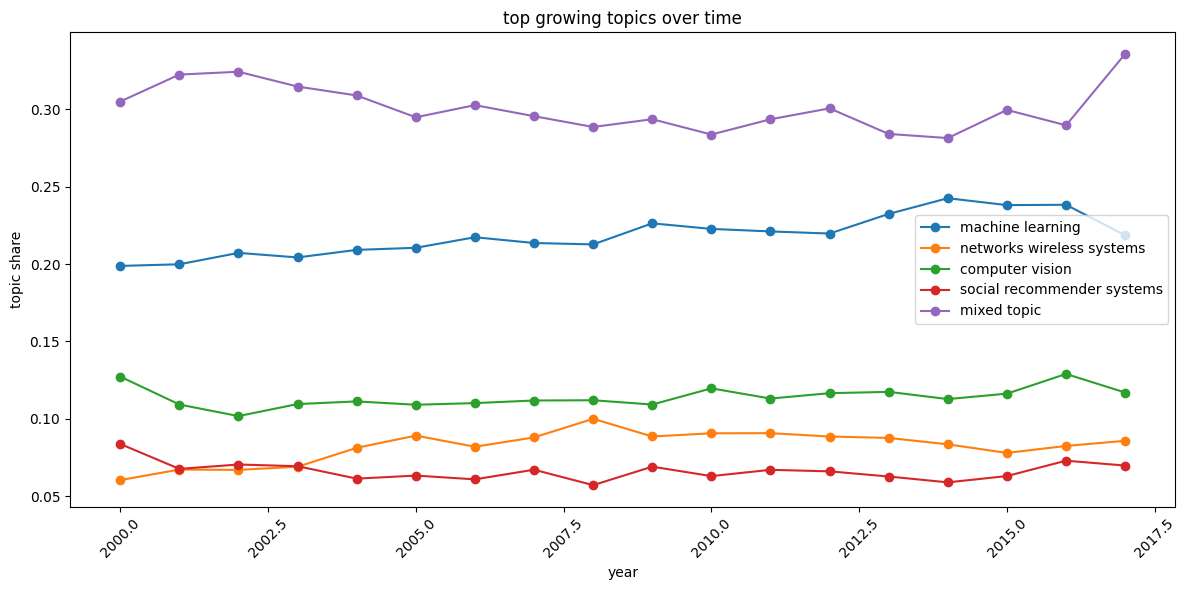

In [13]:
"""plot growing topics"""
top_growing_topics = (
    topic_growth
    .head(5)["topic_label"]
    .tolist()
)
growth_plot_data = topic_by_year[
    topic_by_year["topic_label"].isin(top_growing_topics)
]
plt.figure(figsize=(12, 6))
for topic_label in top_growing_topics:
    topic_line = growth_plot_data[
        growth_plot_data["topic_label"] == topic_label
    ]
    plt.plot(
        topic_line["year"],
        topic_line["topic_share"],
        marker="o",
        label=topic_label
    )
plt.title("top growing topics over time")
plt.xlabel("year")
plt.ylabel("topic share")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
"""compare topics across venues"""
venue_counts = topic_sample["venue"].value_counts()
major_venues = (
    venue_counts[venue_counts.index != ""]
    .head(TOP_VENUES)
    .index
)
venue_topic_data = topic_sample[
    topic_sample["venue"].isin(major_venues)
]
venue_topic_table = pd.crosstab(
    venue_topic_data["venue"],
    venue_topic_data["topic_label"],
    normalize="index"
)
venue_topic_table

topic_label,computer vision,data mining databases,machine learning,mixed topic,networks wireless systems,social recommender systems
venue,,,,,,
Applied Mathematics and Computation,0.025641,0.018315,0.126374,0.701465,0.009158,0.119048
Lecture Notes in Computer Science,0.105478,0.332788,0.217498,0.230581,0.070319,0.043336
global communications conference,0.010720,0.049005,0.044410,0.506891,0.366003,0.022971
intelligent robots and systems,0.181474,0.069943,0.120983,0.156900,0.026465,0.444234
"international conference on acoustics, speech, and signal processing",0.284561,0.021191,0.211907,0.418769,0.043391,0.020182
international conference on communications,0.011645,0.065502,0.062591,0.486172,0.350801,0.023290
international conference on image processing,0.722689,0.018487,0.102521,0.132773,0.006723,0.016807
international conference on robotics and automation,0.146667,0.051667,0.143333,0.151667,0.021667,0.485000
international geoscience and remote sensing symposium,0.331269,0.055728,0.482972,0.116099,0.010836,0.003096


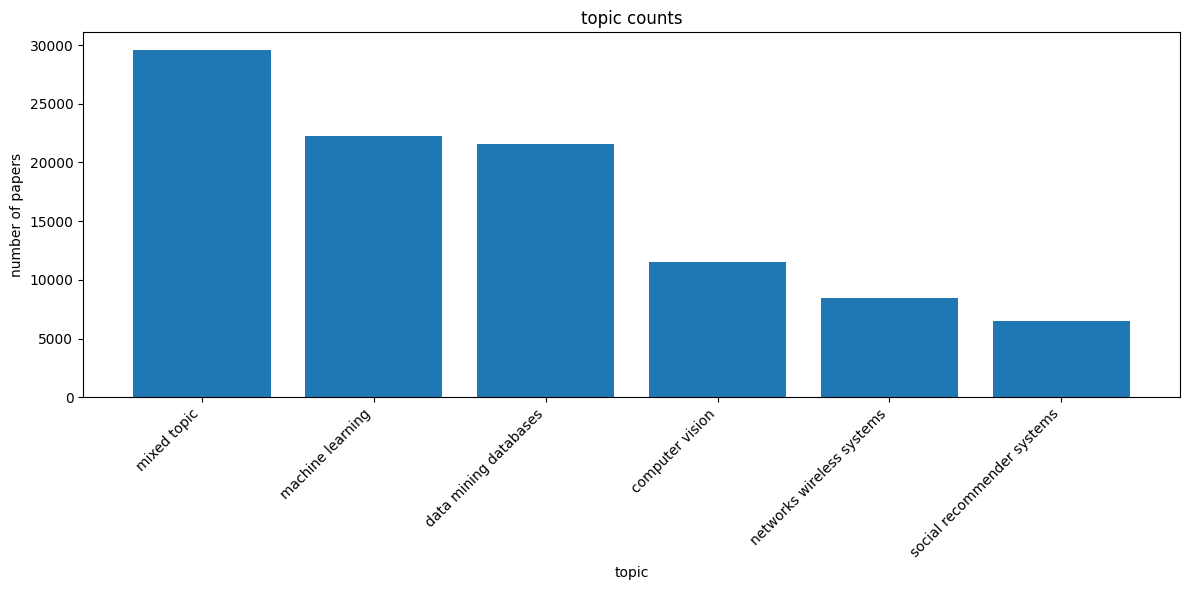

In [15]:
"plot topic counts"
plt.figure(figsize=(12, 6))
plt.bar(topic_counts["topic_label"], topic_counts["paper_count"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("topic")
plt.ylabel("number of papers")
plt.title("topic counts")
plt.tight_layout()
plt.show()

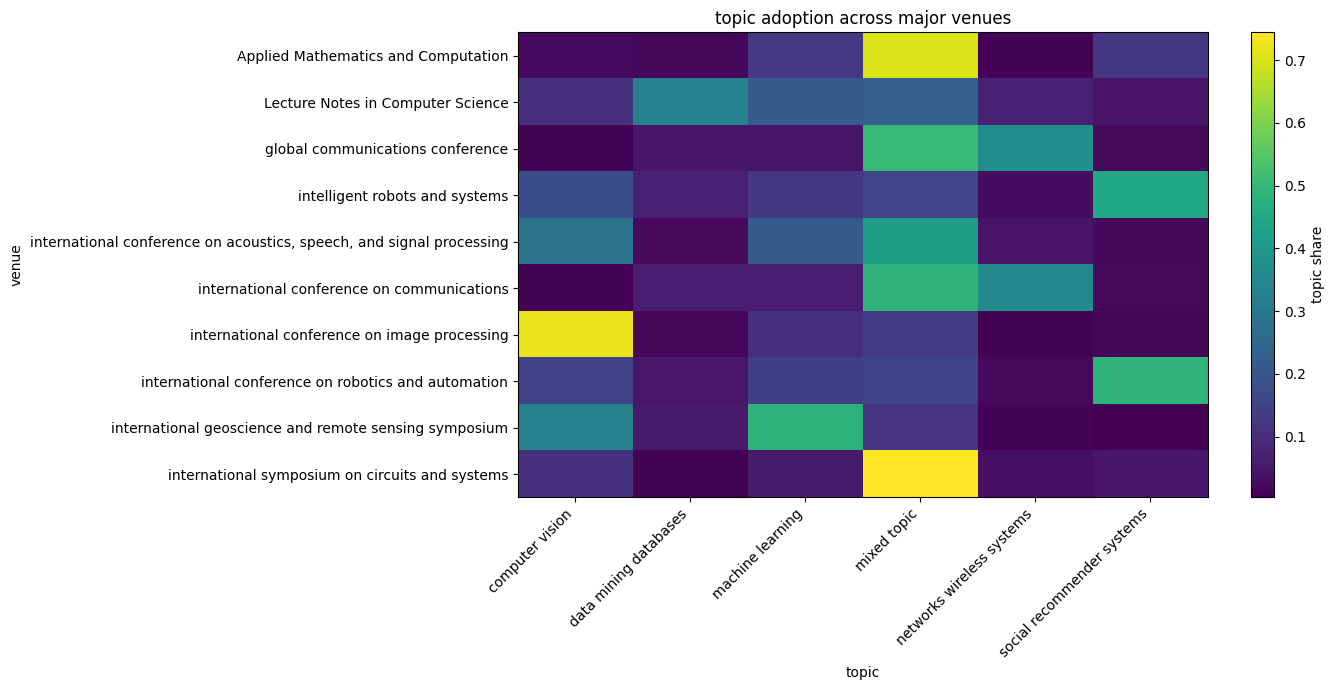

In [16]:
"""plot venue topic adoption"""
plt.figure(figsize=(14, 7))
plt.imshow(
    venue_topic_table,
    aspect="auto"
)
plt.xticks(
    range(len(venue_topic_table.columns)),
    venue_topic_table.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(venue_topic_table.index)),
    venue_topic_table.index
)
plt.colorbar(label="topic share")
plt.title("topic adoption across major venues")
plt.xlabel("topic")
plt.ylabel("venue")
plt.tight_layout()
plt.show()

In [17]:
"""show case studies for growing topics"""
case_studies = []
for topic_label in top_growing_topics[:TOP_CASES]:
    topic_cases = (
        topic_sample[topic_sample["topic_label"] == topic_label]
        .sort_values(
            ["dominant_topic_weight", "n_citation"],
            ascending=False
        )
        .head(1)
    )
    case_studies.append(topic_cases)
case_studies = pd.concat(case_studies)
case_studies[[
    "title",
    "venue",
    "year",
    "n_citation",
    "topic_label",
    "dominant_topic_weight"
]]

,title,venue,year,n_citation,topic_label,dominant_topic_weight
15632,Development of an adaptive learning system wit...,Computers in Education,2008,269,machine learning,0.162531
72690,Routing in mobile wireless sensor network: a s...,Telecommunication Systems,2014,50,networks wireless systems,0.112869
37247,A ROI image retrieval method based on CVAAO,Image and Vision Computing,2008,29,computer vision,0.107338


In [18]:
"topic counts by year"
year_topic_counts = (
    topic_sample
    .groupby(["year", "topic_label"])
    .size()
    .reset_index(name="paper_count")
)
year_totals = (
    topic_sample
    .groupby("year")
    .size()
    .reset_index(name="year_total")
)
year_topic_counts = year_topic_counts.merge(year_totals, on="year", how="left")
year_topic_counts["topic_percentage"] = (
    year_topic_counts["paper_count"] /
    year_topic_counts["year_total"] *
    100
)
year_topic_counts.head()

,year,topic_label,paper_count,year_total,topic_percentage
0,2000,computer vision,246,1932,12.732919
1,2000,data mining databases,434,1932,22.463768
2,2000,machine learning,384,1932,19.875776
3,2000,mixed topic,589,1932,30.486542
4,2000,networks wireless systems,117,1932,6.055901


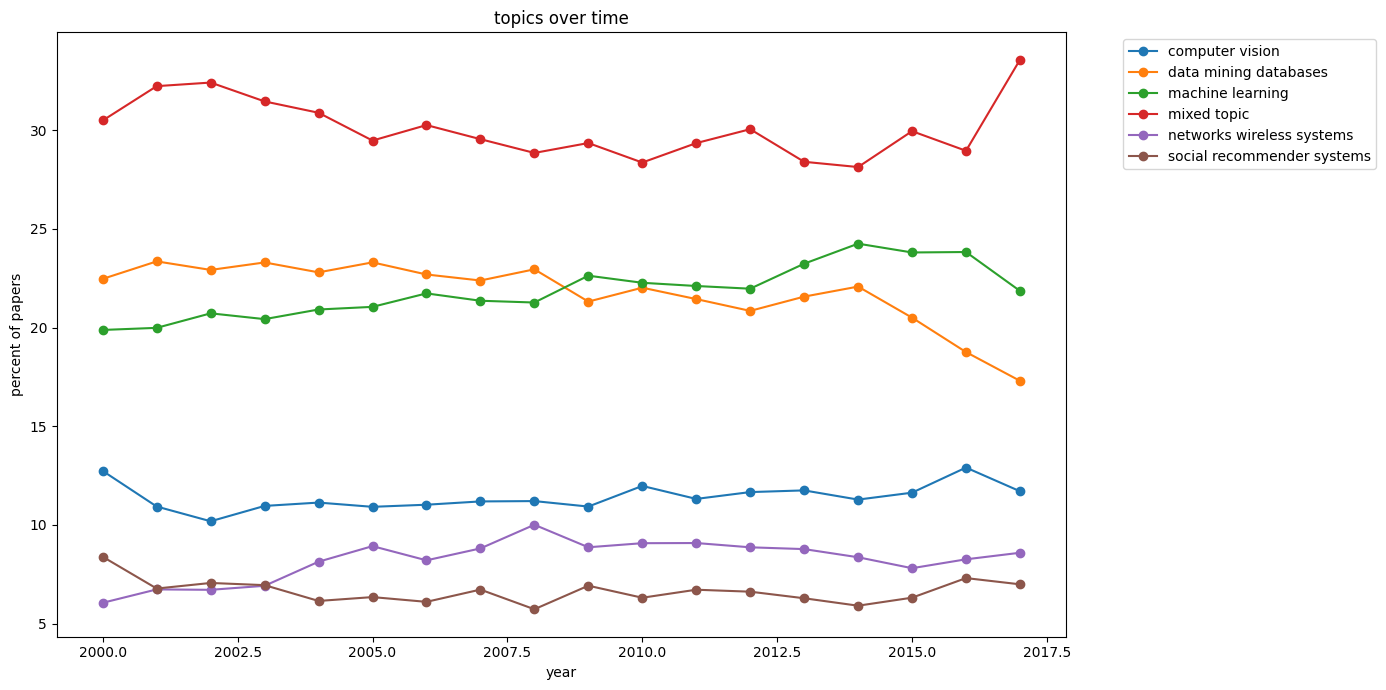

In [19]:
"plot topics over time"
plt.figure(figsize=(14, 7))

for topic_label in sorted(year_topic_counts["topic_label"].unique()):
    topic_trend = year_topic_counts[
        year_topic_counts["topic_label"] == topic_label
    ]
    plt.plot(
        topic_trend["year"],
        topic_trend["topic_percentage"],
        marker="o",
        label=topic_label
    )
plt.xlabel("year")
plt.ylabel("percent of papers")
plt.title("topics over time")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [20]:
"find topics that grew the most"
early_period = topic_sample[
    (topic_sample["year"] >= 2000) &
    (topic_sample["year"] <= 2005)
]
late_period = topic_sample[
    (topic_sample["year"] >= 2012) &
    (topic_sample["year"] <= 2017)
]
early_topic_share = (
    early_period["topic_label"]
    .value_counts(normalize=True)
    .reset_index()
)
early_topic_share.columns = ["topic_label", "early_share"]
late_topic_share = (
    late_period["topic_label"]
    .value_counts(normalize=True)
    .reset_index()
)
late_topic_share.columns = ["topic_label", "late_share"]
topic_growth = topic_keywords[["topic_label"]].drop_duplicates()
topic_growth = topic_growth.merge(early_topic_share, on="topic_label", how="left")
topic_growth = topic_growth.merge(late_topic_share, on="topic_label", how="left")
topic_growth["early_share"] = topic_growth["early_share"].fillna(0)
topic_growth["late_share"] = topic_growth["late_share"].fillna(0)
topic_growth["growth_change"] = topic_growth["late_share"] - topic_growth["early_share"]
topic_growth["growth_percentage_points"] = topic_growth["growth_change"] * 100
topic_growth = topic_growth.sort_values(
    "growth_percentage_points",
    ascending=False
)
topic_growth

,topic_label,early_share,late_share,growth_change,growth_percentage_points
4,machine learning,0.206092,0.233164,0.027071,2.707144
2,networks wireless systems,0.075302,0.084228,0.008927,0.892660
3,computer vision,0.110593,0.118508,0.007916,0.791556
5,social recommender systems,0.067783,0.065267,-0.002516,-0.251552
0,mixed topic,0.309660,0.293644,-0.016016,-1.601596
1,data mining databases,0.230571,0.205189,-0.025382,-2.538212


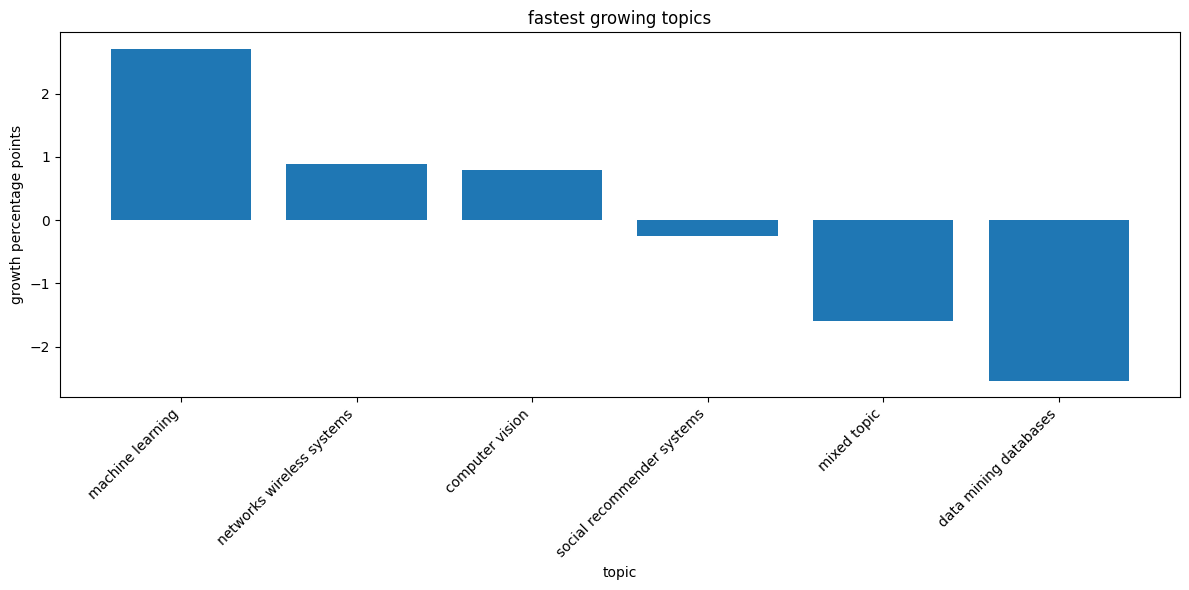

In [21]:
"plot growing topics"
top_growth = topic_growth.head(8)
plt.figure(figsize=(12, 6))
plt.bar(top_growth["topic_label"], top_growth["growth_percentage_points"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("topic")
plt.ylabel("growth percentage points")
plt.title("fastest growing topics")
plt.tight_layout()
plt.show()

In [22]:
"topic lifecycle table"
topic_lifecycle_rows = []
for topic_label in sorted(year_topic_counts["topic_label"].unique()):
    trend = year_topic_counts[
        year_topic_counts["topic_label"] == topic_label
    ].copy()
    peak_row = trend.loc[trend["topic_percentage"].idxmax()]
    early_avg = trend[trend["year"].between(2000, 2005)]["topic_percentage"].mean()
    middle_avg = trend[trend["year"].between(2006, 2011)]["topic_percentage"].mean()
    late_avg = trend[trend["year"].between(2012, 2017)]["topic_percentage"].mean()
    topic_lifecycle_rows.append({
        "topic_label": topic_label,
        "peak_year": int(peak_row["year"]),
        "peak_percentage": peak_row["topic_percentage"],
        "early_avg_percentage": early_avg,
        "middle_avg_percentage": middle_avg,
        "late_avg_percentage": late_avg
    })
topic_lifecycle = pd.DataFrame(topic_lifecycle_rows)
topic_lifecycle = topic_lifecycle.sort_values(
    "late_avg_percentage",
    ascending=False
)
topic_lifecycle

,topic_label,peak_year,peak_percentage,early_avg_percentage,middle_avg_percentage,late_avg_percentage
3,mixed topic,2017,33.559728,31.152854,29.279310,29.837099
2,machine learning,2014,24.246466,20.492914,21.890101,23.153685
1,data mining databases,2001,23.349366,23.019610,22.130333,20.171786
0,computer vision,2016,12.904779,11.143385,11.273974,11.823236
4,networks wireless systems,2008,10.008326,7.246996,9.008319,8.443304
5,social recommender systems,2000,8.385093,6.944240,6.417963,6.570890


In [23]:
"look at topics by venue"
venue_counts = (
    topic_sample[topic_sample["venue"] != ""]
    ["venue"]
    .value_counts()
)
top_venues = venue_counts.head(10).index.tolist()
venue_topic_data = topic_sample[
    topic_sample["venue"].isin(top_venues)
].copy()
venue_topic_counts = (
    venue_topic_data
    .groupby(["venue", "topic_label"])
    .size()
    .reset_index(name="paper_count")
)
venue_totals = (
    venue_topic_data
    .groupby("venue")
    .size()
    .reset_index(name="venue_total")
)
venue_topic_counts = venue_topic_counts.merge(
    venue_totals,
    on="venue",
    how="left"
)
venue_topic_counts["topic_percentage"] = (
    venue_topic_counts["paper_count"] /
    venue_topic_counts["venue_total"] *
    100
)
venue_topic_counts.head()

,venue,topic_label,paper_count,venue_total,topic_percentage
0,Applied Mathematics and Computation,computer vision,14,546,2.564103
1,Applied Mathematics and Computation,data mining databases,10,546,1.831502
2,Applied Mathematics and Computation,machine learning,69,546,12.637363
3,Applied Mathematics and Computation,mixed topic,383,546,70.146520
4,Applied Mathematics and Computation,networks wireless systems,5,546,0.915751


In [24]:
"venue topic table"
venue_topic_pivot = venue_topic_counts.pivot_table(
    index="venue",
    columns="topic_label",
    values="topic_percentage",
    fill_value=0
)
venue_topic_pivot

topic_label,computer vision,data mining databases,machine learning,mixed topic,networks wireless systems,social recommender systems
venue,,,,,,
Applied Mathematics and Computation,2.564103,1.831502,12.637363,70.146520,0.915751,11.904762
Lecture Notes in Computer Science,10.547833,33.278823,21.749796,23.058054,7.031889,4.333606
global communications conference,1.071975,4.900459,4.441041,50.689127,36.600306,2.297090
intelligent robots and systems,18.147448,6.994329,12.098299,15.689981,2.646503,44.423440
"international conference on acoustics, speech, and signal processing",28.456105,2.119072,21.190716,41.876892,4.339051,2.018163
international conference on communications,1.164483,6.550218,6.259098,48.617176,35.080058,2.328967
international conference on image processing,72.268908,1.848739,10.252101,13.277311,0.672269,1.680672
international conference on robotics and automation,14.666667,5.166667,14.333333,15.166667,2.166667,48.500000
international geoscience and remote sensing symposium,33.126935,5.572755,48.297214,11.609907,1.083591,0.309598


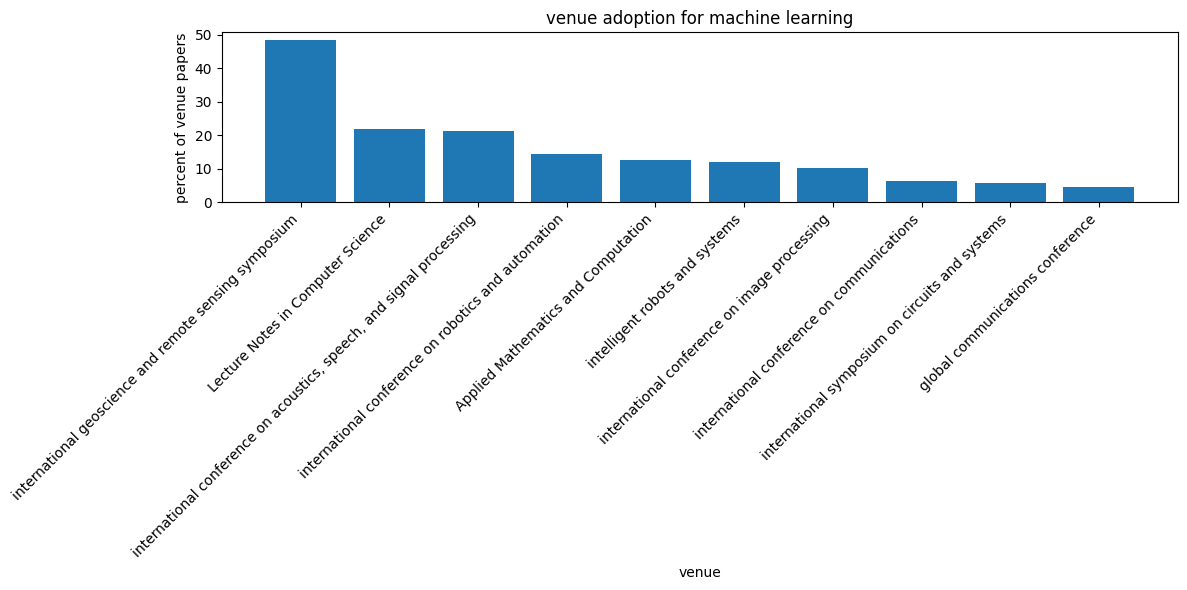

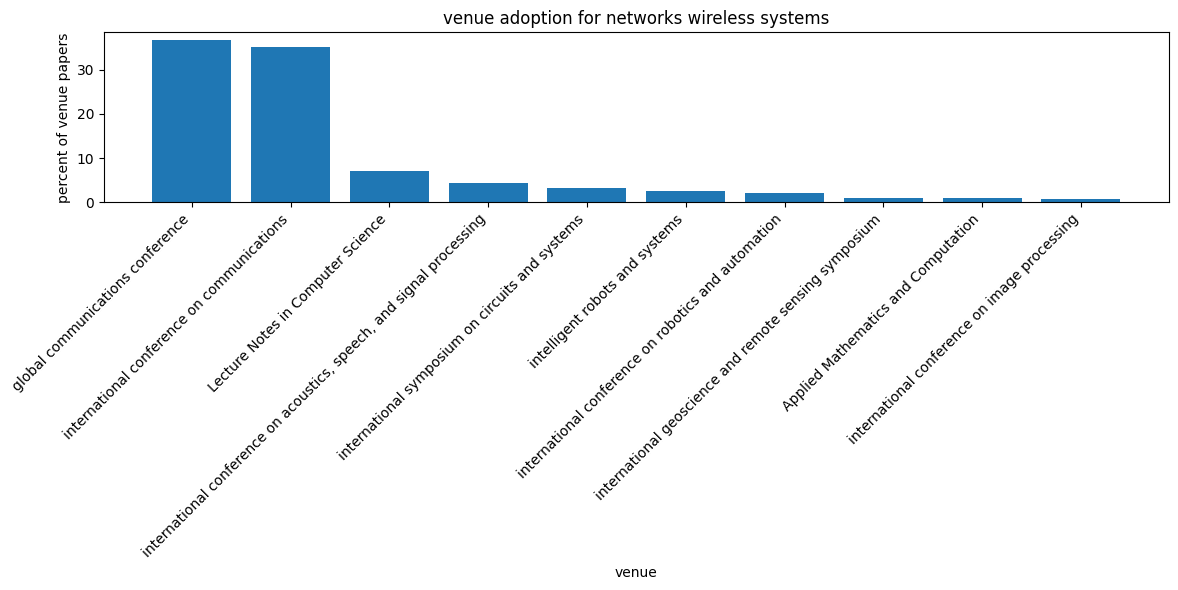

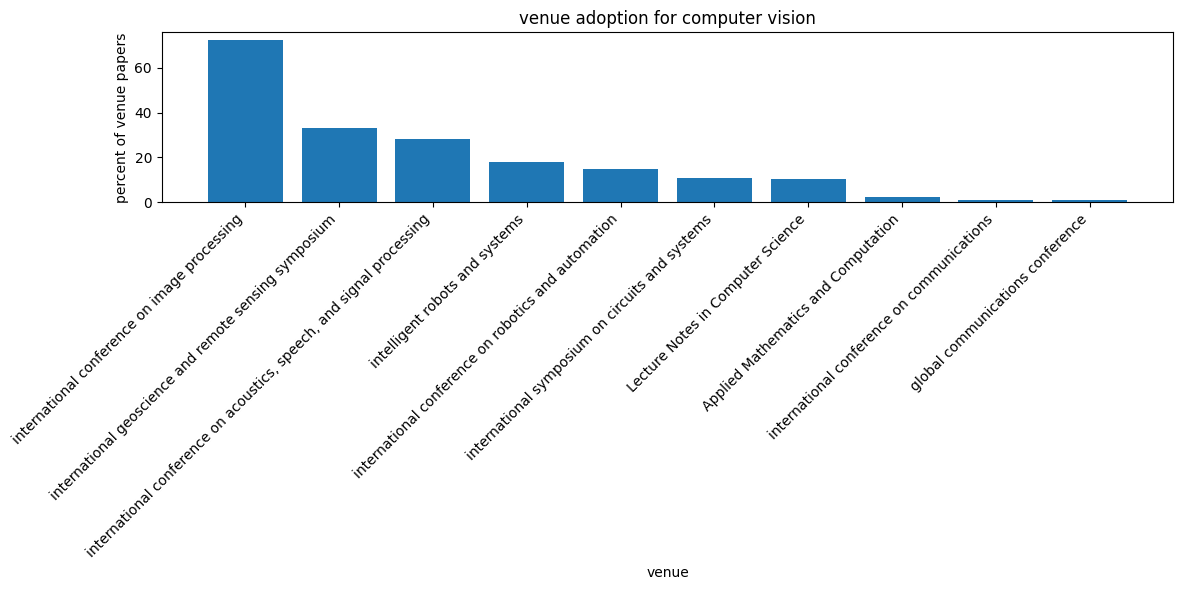

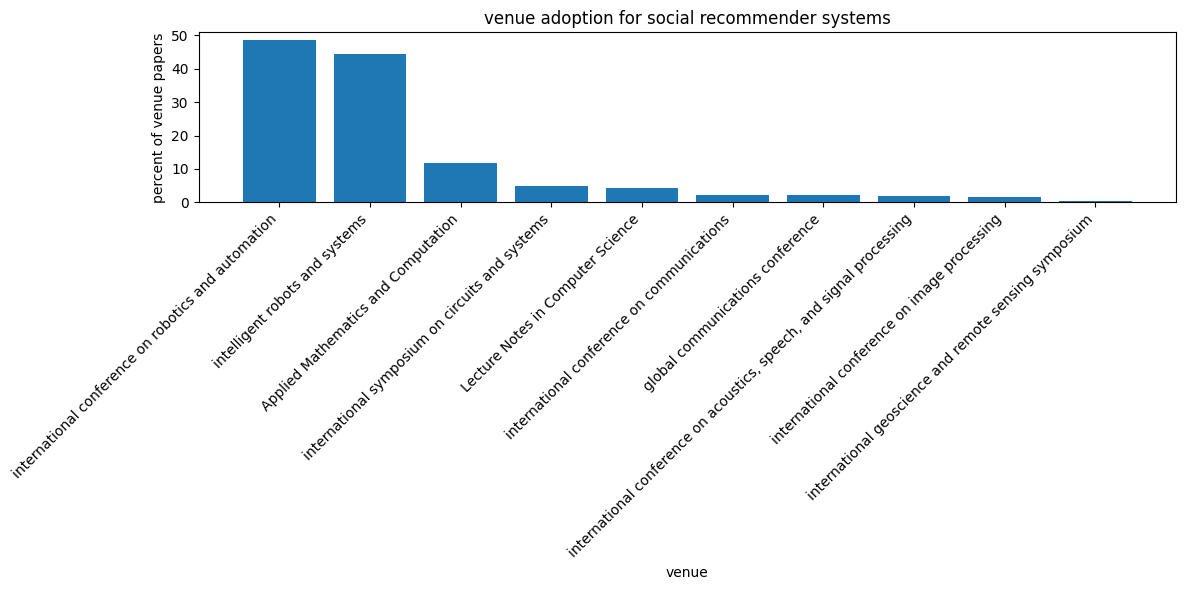

In [25]:
"plot top growing topics by venue"
selected_topics = topic_growth.head(4)["topic_label"].tolist()
for selected_topic in selected_topics:
    plot_data = venue_topic_counts[
        venue_topic_counts["topic_label"] == selected_topic
    ].sort_values("topic_percentage", ascending=False)
    plt.figure(figsize=(12, 6))
    plt.bar(plot_data["venue"], plot_data["topic_percentage"])
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("venue")
    plt.ylabel("percent of venue papers")
    plt.title(f"venue adoption for {selected_topic}")
    plt.tight_layout()
    plt.show()

In [26]:
"case study papers"
case_study_rows = []
for topic_label in topic_growth.head(5)["topic_label"]:
    topic_examples = (
        topic_sample[topic_sample["topic_label"] == topic_label]
        .sort_values(
            ["dominant_topic_weight", "n_citation"],
            ascending=False
        )
        .head(3)
    )
    for _, row in topic_examples.iterrows():
        case_study_rows.append({
            "topic_label": topic_label,
            "title": row["title"],
            "venue": row["venue"],
            "year": row["year"],
            "n_citation": row["n_citation"],
            "topic_weight": row["dominant_topic_weight"]
        })
case_studies = pd.DataFrame(case_study_rows)
case_studies

,topic_label,title,venue,year,n_citation,topic_weight
0,machine learning,Development of an adaptive learning system wit...,Computers in Education,2008,269,0.162531
1,machine learning,Spiraling into Transformative Learning,International Journal of Adult Vocational Educ...,2010,50,0.160205
2,machine learning,Identifying Middlewares for Mashup Personal Le...,Future Internet,2009,13,0.156218
3,networks wireless systems,Routing in mobile wireless sensor network: a s...,Telecommunication Systems,2014,50,0.112869
4,networks wireless systems,A new routing protocol for WBAN to enhance ene...,international conference of distributed comput...,2016,10,0.110859
5,networks wireless systems,A Neural Networks-Based Hybrid Routing Protoco...,Sensors,2012,50,0.110831
6,computer vision,A ROI image retrieval method based on CVAAO,Image and Vision Computing,2008,29,0.107338
7,computer vision,Effective image splicing detection based on im...,international conference on image processing,2009,89,0.102362
8,computer vision,Gabor filter and eigen-flame image-based burni...,conference on decision and control,2011,50,0.100824
9,social recommender systems,Trajectory tracking for an autonomous airship ...,Journal of Zhejiang University Science C,2012,50,0.138883


In [27]:
"case study papers"
case_study_rows = []
for topic_label in topic_growth.head(5)["topic_label"]:
    topic_examples = (
        topic_sample[topic_sample["topic_label"] == topic_label]
        .sort_values(
            ["dominant_topic_weight", "n_citation"],
            ascending=False
        )
        .head(3)
    )
    for _, row in topic_examples.iterrows():
        case_study_rows.append({
            "topic_label": topic_label,
            "title": row["title"],
            "venue": row["venue"],
            "year": row["year"],
            "n_citation": row["n_citation"],
            "topic_weight": row["dominant_topic_weight"]
        })
case_studies = pd.DataFrame(case_study_rows)
case_studies

,topic_label,title,venue,year,n_citation,topic_weight
0,machine learning,Development of an adaptive learning system wit...,Computers in Education,2008,269,0.162531
1,machine learning,Spiraling into Transformative Learning,International Journal of Adult Vocational Educ...,2010,50,0.160205
2,machine learning,Identifying Middlewares for Mashup Personal Le...,Future Internet,2009,13,0.156218
3,networks wireless systems,Routing in mobile wireless sensor network: a s...,Telecommunication Systems,2014,50,0.112869
4,networks wireless systems,A new routing protocol for WBAN to enhance ene...,international conference of distributed comput...,2016,10,0.110859
5,networks wireless systems,A Neural Networks-Based Hybrid Routing Protoco...,Sensors,2012,50,0.110831
6,computer vision,A ROI image retrieval method based on CVAAO,Image and Vision Computing,2008,29,0.107338
7,computer vision,Effective image splicing detection based on im...,international conference on image processing,2009,89,0.102362
8,computer vision,Gabor filter and eigen-flame image-based burni...,conference on decision and control,2011,50,0.100824
9,social recommender systems,Trajectory tracking for an autonomous airship ...,Journal of Zhejiang University Science C,2012,50,0.138883


In [28]:
"save tables"
os.makedirs("outputs", exist_ok=True)
topic_keywords.to_csv("outputs/emerging_topic_keywords.csv", index=False)
topic_growth.to_csv("outputs/emerging_topic_growth.csv", index=False)
topic_lifecycle.to_csv("outputs/emerging_topic_lifecycle.csv", index=False)
venue_topic_pivot.to_csv("outputs/venue_topic_adoption.csv")
case_studies.to_csv("outputs/emerging_topic_case_studies.csv", index=False)
print("saved tables")

saved tables
